In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning) #ignores warnings while bulid
#importing all required python libraries
import pandas as pd

import numpy as np
import os
import matplotlib.pyplot as plt #use to visualize dataset values
from minepy import MINE #loading class to select features using MIC (Maximal Information Coefficient)

from sklearn.preprocessing import MinMaxScaler

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.metrics import roc_curve

from sklearn.ensemble import RandomForestClassifier

from sklearn import svm

#CNN and LSTM
from keras.utils.np_utils import to_categorical
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Flatten, LSTM, Dropout
from keras.layers import Convolution2D
from keras.models import Sequential
import pickle
from keras.callbacks import ModelCheckpoint

In [4]:
#loading and displaying IOT intrusion dataset
dataset = pd.read_csv("Dataset/IoT_Network_Intrusion.csv", nrows=10000)
dataset

,index,Src_Port,Dst_Port,Protocol,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,TotLen_Fwd_Pkts,TotLen_Bwd_Pkts,Fwd_Pkt_Len_Max,...,Dst_1,Dst_2,Dst_3,Date,Month,Hour,Minute,Seconds,AM/PM,label
0,17,-1.138106,2.004022,-0.694809,-0.179158,-0.196043,-0.354896,-0.295937,0.326101,-0.393593,...,0.62365,-0.794672,-0.709910,0.148069,-1.414987,0.112918,1.775813,0.174984,0,1
1,33,-1.138106,2.185859,-0.694809,-0.172399,-0.196043,-0.354896,-0.295937,0.326101,-0.393593,...,0.62365,-0.794672,-0.709910,-1.840901,1.690085,-0.233242,1.654815,0.002351,0,0
2,38,-1.220703,-0.851415,-0.694809,0.754273,0.567610,0.354889,-0.322974,-0.375599,-0.454420,...,0.62365,-0.794672,-0.769741,0.893933,-1.414987,2.189877,-1.249132,1.210788,1,0
3,45,0.652199,-0.360371,-0.694809,-0.177993,-0.196043,-0.354896,-0.322974,-0.375599,-0.454420,...,0.62365,-0.794672,-0.769741,-0.970727,0.137549,-0.925562,-0.704642,0.462708,0,0
4,47,-1.138106,2.004022,-0.694809,-0.190112,-0.386957,0.354889,-0.322974,-0.375599,-0.454420,...,0.62365,-0.794672,-0.709910,0.148069,-1.414987,0.112918,1.836312,1.613600,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,66308,-1.138106,2.004022,-0.694809,-0.115764,0.185784,-0.354896,2.205886,0.326101,2.359863,...,0.62365,-0.794672,-0.709910,0.148069,-1.414987,0.112918,1.896811,-1.090997,0,1
9996,66332,-1.138106,2.004022,-0.694809,-0.111569,0.376697,-0.354896,3.456798,0.326101,2.359863,...,0.62365,-0.794672,-0.709910,0.148069,-1.414987,0.112918,1.896811,0.059895,0,1
9997,66334,-1.138106,2.004022,-0.694809,-0.137905,0.185784,-0.354896,2.205886,0.326101,2.359863,...,0.62365,-0.794672,-0.709910,0.148069,-1.414987,0.112918,1.836312,1.210788,0,1
9998,66340,-1.489513,1.624341,-0.694809,-0.189413,-0.196043,-0.354896,0.975703,0.352895,2.467325,...,0.62365,-0.794672,-0.550360,0.769622,0.137549,-0.233242,-0.341649,0.692886,0,0


In [5]:
#finding sum of missing values
dataset.isnull().sum()

index            0
Src_Port         0
Dst_Port         0
Protocol         0
Flow_Duration    0
                ..
Hour             0
Minute           0
Seconds          0
AM/PM            0
label            0
Length: 77, dtype: int64

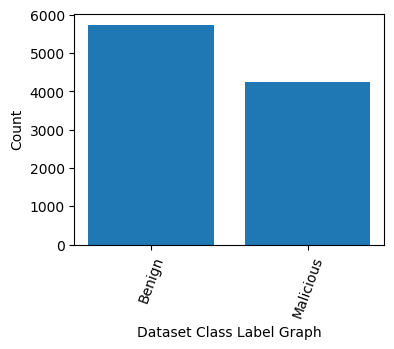

In [6]:
#visualizing Sub Attack class labels count found in dataset
names, count = np.unique(dataset['label'], return_counts = True)
labels = ['Benign', 'Malicious']
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.figure(figsize = (4, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Dataset Class Label Graph")
plt.ylabel("Count")
plt.xticks(rotation=70)
plt.show()

In [7]:
#applying 'Maximal Information Coefficient' algorithm to select features from dataset which is having high scores
#features with high score will help algorithm in getting better acccuracy
Y = dataset['label'].ravel()
dataset.drop(['index', 'label'], axis = 1,inplace=True)
columns = dataset.columns
X = dataset.values
print("Total Features Found in Dataset before applying MINE Features Selection Algorithm = "+str(X.shape[1]))
if os.path.exists("model/fs.npy"):
    top_features = np.load("model/fs.npy")
else:
    mic_scores = []
    mine = MINE()
    for i in range(0, len(columns)-1):#loop and compute mic score for each features
        mine.compute_score(X[:,i], Y)
        mic_scores.append((columns[i], mine.mic()))
    # Sort features by MIC score
    mic_scores.sort(key=lambda x: x[1], reverse=True)
    # Select top features
    top_features = [feature for feature, _ in mic_scores[:35]]  # Select top 2 features
    top_features = np.asarray(top_features)
    np.save("model/fs", top_features)
X = dataset[top_features]
X = X.values    
print("Total Features Found in Dataset after applying MINE Features Selection Algorithm = "+str(X.shape[1]))
print()
print("Selected Features Names = "+str(top_features))

Total Features Found in Dataset before applying MINE Features Selection Algorithm = 75
Total Features Found in Dataset after applying MINE Features Selection Algorithm = 35

Selected Features Names = ['Hour' 'Minute' 'Src_Port' 'Date' 'Dst_Port' 'Month' 'Init_Bwd_Win_Byts'
 'Flow_Duration' 'Flow_Pkts/s' 'TotLen_Bwd_Pkts' 'Flow_IAT_Max' 'Dst_3'
 'Idle_Max' 'Flow_IAT_Mean' 'Idle_Mean' 'Bwd_Pkts/s' 'TotLen_Fwd_Pkts'
 'Pkt_Size_Avg' 'Fwd_Pkt_Len_Mean' 'Fwd_Pkt_Len_Max' 'Fwd_Pkt_Len_Min'
 'Pkt_Len_Mean' 'Bwd_Pkt_Len_Mean' 'Bwd_Pkt_Len_Min' 'Bwd_Header_Len'
 'Pkt_Len_Max' 'Bwd_Pkt_Len_Max' 'Pkt_Len_Min' 'Idle_Min' 'Flow_IAT_Min'
 'ACK_Flag_Cnt' 'Fwd_Pkts/s' 'Flow_Byts/s' 'Fwd_Header_Len' 'Src_3']


In [8]:
#applying MINMAX scaling algorithm to normalize dataset selected features
scaler = MinMaxScaler((0, 1))
X = scaler.fit_transform(X)
print("Normalized Features = "+str(X))

Normalized Features = [[0.3        0.94915254 0.13923406 ... 0.11539714 0.03478261 0.05098039]
 [0.2        0.91525424 0.13923406 ... 0.09293729 0.03478261 0.05098039]
 [0.9        0.10169492 0.10811478 ... 0.         0.10869565 0.84705882]
 ...
 [0.3        0.96610169 0.13923406 ... 0.13790246 0.10434783 0.05098039]
 [0.2        0.3559322  0.00683821 ... 0.37032278 0.03478261 0.84313725]
 [0.         0.83050847 0.00123489 ... 0.28707005 0.04347826 0.25098039]]


In [9]:
#applying PCA dimension reduction algorithm to reduce dimension by removing irrelevant features
print("Total Features Found in Dataset before applying PCA = "+str(X.shape[1]))
pca = PCA(n_components=30)
X = pca.fit_transform(X)
print("Total Features Found in Dataset after applying PCA = "+str(X.shape[1]))

Total Features Found in Dataset before applying PCA = 35
Total Features Found in Dataset after applying PCA = 30


In [10]:
#shufling and splitting dataset into train and test
indices = np.arange(X.shape[0])

#shuffling dataset
np.random.shuffle(indices)
X = X[indices]
Y = Y[indices]

# Split dataset: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

# Print dataset split details
print("Dataset Train & Test Split Details")
print("80% Text data used to train algorithms : "+str(X_train.shape[0]))
print("20% Text data used to train algorithms : "+str(X_test.shape[0]))


Dataset Train & Test Split Details
80% Text data used to train algorithms : 8000
20% Text data used to train algorithms : 2000


In [11]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [12]:
#function to calculate all metrics
def calculateMetrics(algorithm, testY, predict):
    """
    Computes and displays various classification metrics for a given model.
    
    Parameters:
    algorithm (str): Name of the machine learning model.
    testY (array-like): True class labels of the test dataset.
    predict (array-like): Predicted class labels by the model.

    Outputs:
    - Accuracy, Precision, Recall, and F1-score printed.
    - Confusion Matrix plotted. - needed to be done
    - ROC Curve plotted. - need to be done
    """
    
    # Calculate classification metrics
    p = precision_score(testY, predict,average='macro') * 100 # Precision in percentage
    r = recall_score(testY, predict,average='macro') * 100 # Recall in percentage
    f = f1_score(testY, predict,average='macro') * 100  # F1-score in percentage
    a = accuracy_score(testY,predict)*100 # Accuracy in percentage

    # Storing the metrics in global lists for comparison
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)

    # Printing the calculated metrics
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))

    # Generate and display the Confusion Matrix
    conf_matrix = confusion_matrix(testY, predict)

    # Create a figure with 2 subplots (Confusion Matrix & ROC Curve)
    fig, axs = plt.subplots(1,2,figsize=(10, 3))

    # Plot Confusion Matrix
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(labels)])
    axs[0].set_title(f"{algorithm} - Confusion Matrix")
    axs[0].set_xlabel("Predicted Labels")
    axs[0].set_ylabel("True Labels")

    # Generate ROC Curve
    random_probs = [0 for i in range(len(testY))]

    # Compute ROC for the random baseline
    p_fpr, p_tpr, _ = roc_curve(testY, random_probs, pos_label=1)
    plt.plot(p_fpr, p_tpr, linestyle='--', color='orange',label="True classes")

    # Compute ROC for the model predictions
    ns_fpr, ns_tpr, _ = roc_curve(testY, predict, pos_label=1)
    axs[1].plot(ns_fpr, ns_tpr, linestyle='--', label='Predicted Classes')

     # Customize ROC Curve plot
    axs[1].set_title(f"{algorithm} - ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    plt.show()

Random Forest Accuracy  : 98.5
Random Forest Precision : 98.27957253333251
Random Forest Recall    : 98.66924564796905
Random Forest FSCORE    : 98.4590587314355


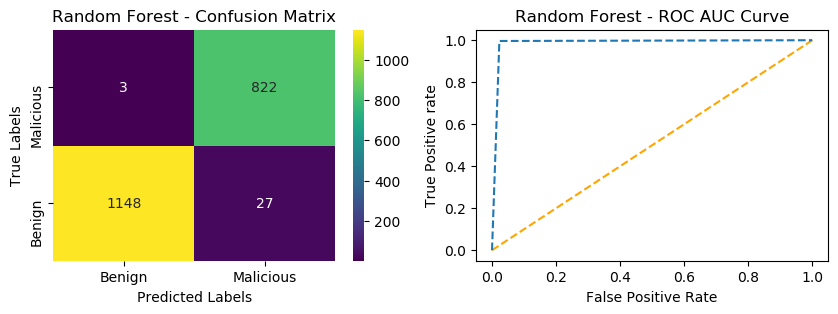

In [13]:
# Train Random Forest algorithms on 80% training features and then apply trained model on 20% test

# Train a Random Forest classifier on 80% of the training data
# n_estimators=2 means the forest has only 2 decision trees
rf_cls = RandomForestClassifier(n_estimators=2) #There is no much difference in the model performence so rather then given more decision tree we given the minimum.
rf_cls.fit(X_train, y_train) # Fit model to training data

# Call this function to predict on test data
predict = rf_cls.predict(X_test)

# Call this function to calculate accuracy and other metrics
calculateMetrics("Random Forest", predict, y_test)

SVM Accuracy  : 94.3
SVM Precision : 94.05883550842766
SVM Recall    : 94.25920690807227
SVM FSCORE    : 94.15406200386447


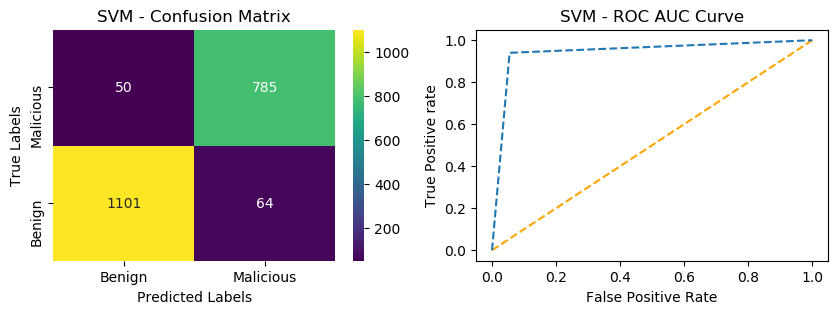

In [14]:
# Train SVM algorithms on 80% training features and then apply trained model on 20% test

# Features to calculate prediction accuracy
svm_cls = svm.SVC(kernel='sigmoid')

# Train the SVM model using 80% of the training data
svm_cls.fit(X_train, y_train)

# Call this function to predict on test data
predict = svm_cls.predict(X_test)

# Call this function to calculate accuracy and other metrics
calculateMetrics("SVM", predict, y_test)



CNN2D Accuracy  : 100.0
CNN2D Precision : 100.0
CNN2D Recall    : 100.0
CNN2D FSCORE    : 100.0


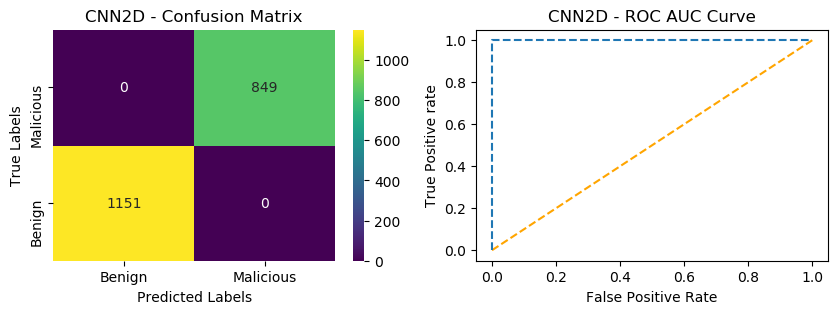

In [15]:
#train CNN2D convolution neural network algorithm on training features and evaluate performance on test data

# Reshape the input data for 2D Convolutional Neural Network
# CNN2D expects a 4D input: (samples, height, width, channels)
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1, 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1, 1))

# Convert labels into one-hot encoded format for multi-class classification
y_train1 = to_categorical(y_train)
y_test1 = to_categorical(y_test)

# Definig CNN object
cnn_model = Sequential()

# Defining First convolutional layer with 32 neurons of 1 X 1 matrix to filter features 32 times
cnn_model.add(Convolution2D(32, (1 , 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))

# MaxPooling layer to reduce dimensions (here it doesn't change much due to (1,1) pooling size)
cnn_model.add(MaxPooling2D(pool_size = (1, 1)))

# Second convolutional layer to further extract features
cnn_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (1, 1)))

# Flatten the 2D output to 1D to feed into dense layers
cnn_model.add(Flatten())

# Dense (fully connected) layer with 256 neurons and ReLU activation
cnn_model.add(Dense(units = 256, activation = 'relu'))

# Output layer with softmax activation for classification (benign vs malicious)
cnn_model.add(Dense(units = y_train1.shape[1], activation = 'softmax'))

#compiling, training and loading model
cnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/cnn_weights.hdf5") == False:
    # Save only the best model during training
    model_check_point = ModelCheckpoint(filepath='model/cnn_weights.hdf5', verbose = 1, save_best_only = True)

    # Train the model
    hist = cnn_model.fit(
        X_train1, y_train1,
        batch_size = 16,
        epochs = 20, 
        validation_data=(X_test1, y_test1),
        callbacks=[model_check_point],
        verbose=1
    )

    # Save the training history to a file for future use
    f = open('model/cnn_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    # Load pre-trained weights if available
    cnn_model.load_weights("model/cnn_weights.hdf5")

# Predict using the trained CNN model on the test data
predict = cnn_model.predict(X_test1)

# Convert one-hot predictions and true labels back to class labels
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test1, axis=1)

# Call this function to calculate accuracy and other metrics
calculateMetrics("CNN2D", predict, y_test)

LSTM Accuracy  : 96.65
LSTM Precision : 96.54865590325001
LSTM Recall    : 96.59228257351344
LSTM FSCORE    : 96.5702365640937


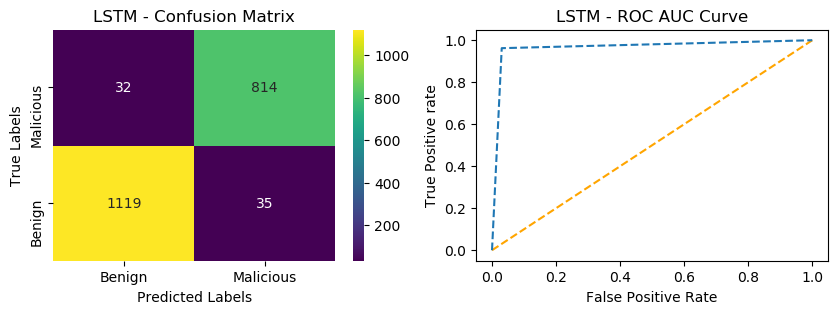

In [16]:
# Reshape the input features for LSTM
# LSTM expects 3D input: (samples, timesteps, features)
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# One-hot encode the target labels for classification
y_train1 = to_categorical(y_train)
y_test1 = to_categorical(y_test)

# Defining deep learning sequential object
lstm_model = Sequential()

# Adding LSTM layer with 100 filters to filter given input X train data to select relevant features
lstm_model.add(LSTM(32,input_shape=(X_train1.shape[1], X_train1.shape[2])))

# Adding dropout layer to remove irrelevant features
lstm_model.add(Dropout(0.2))

# Add a Dense (fully connected) layer with 32 neurons and ReLU activation
lstm_model.add(Dense(32, activation='relu'))

# Defining output layer for prediction
lstm_model.add(Dense(y_train1.shape[1], activation='softmax'))

# Compile the model with categorical crossentropy loss and Adam optimizer
lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Start training model on train data and perform validation on test data
# Train and load the model
if os.path.exists("model/lstm_weights.hdf5") == False:
    # Compile the model with categorical crossentropy loss and Adam optimizer
    model_check_point = ModelCheckpoint(filepath='model/lstm_weights.hdf5', verbose = 1, save_best_only = True)
    
    # Train the model on training data and validate on test data
    hist = lstm_model.fit(X_train1, y_train1, batch_size = 16, epochs = 20, validation_data=(X_test1, y_test1), callbacks=[model_check_point], verbose=1)
    
    # Save the training history for later analysis
    f = open('model/lstm_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()
else:
    # Load previously saved best model weights if they exist
    lstm_model.load_weights("model/lstm_weights.hdf5")

# Evaluate the model on test data
# Perform prediction on test data
predict = lstm_model.predict(X_test1)

# Convert probabilities to class labels
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test1, axis=1)

# Calculate and print accuracy, precision, recall, f-score, confusion matrix, and ROC curve
calculateMetrics("LSTM", predict, y_test)

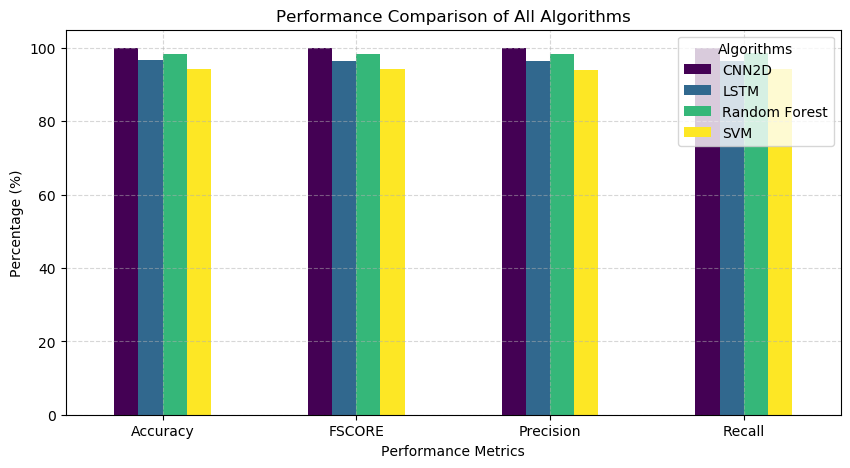

In [28]:
# Create a DataFrame to hold all metric results for each algorithm
df = pd.DataFrame([
    ['Random Forest', 'Accuracy',  accuracy[0]],
    ['Random Forest', 'Precision', precision[0]],
    ['Random Forest', 'Recall',    recall[0]],
    ['Random Forest', 'FSCORE',    fscore[0]],

    ['SVM',           'Accuracy',  accuracy[1]],
    ['SVM',           'Precision', precision[1]],
    ['SVM',           'Recall',    recall[1]],
    ['SVM',           'FSCORE',    fscore[1]],

    ['CNN2D',         'Accuracy',  accuracy[2]],
    ['CNN2D',         'Precision', precision[2]],
    ['CNN2D',         'Recall',    recall[2]],
    ['CNN2D',         'FSCORE',    fscore[2]],

    ['LSTM',          'Accuracy',  accuracy[3]],
    ['LSTM',          'Precision', precision[3]],
    ['LSTM',          'Recall',    recall[3]],
    ['LSTM',          'FSCORE',    fscore[3]],
], columns=['Algorithms', 'Parameters', 'Value'])

# Pivot the DataFrame to make it suitable for plotting
pivot_df = df.pivot(index='Parameters', columns='Algorithms', values='Value')

# Plot the performance of all algorithms as a bar chart
pivot_df.plot(kind='bar', figsize=(10, 5), colormap='viridis')

# Set chart title and labels
plt.title("Performance Comparison of All Algorithms")
plt.ylabel("Percentage (%)")
plt.xlabel("Performance Metrics")
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Algorithms', loc='best')

# Display the plot
# plt.tight_layout()
plt.show()


In [30]:
# List of algorithm names in order of evaluation
algorithms = ['Random Forest', 'SVM', 'CNN2D', 'LSTM']

# Initialize a list to store performance metric rows
data = []

# Loop through the metrics and add them to the data list
for i in range(len(accuracy)):
    data.append([
        algorithms[i],     # Algorithm Name
        accuracy[i],       # Accuracy
        precision[i],      # Precision
        recall[i],         # Recall
        fscore[i]          # F1-Score
    ])

# Convert the list to a pandas DataFrame
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])

# Display the DataFrame
data 

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,Random Forest,98.50,98.279573,98.669246,98.459059
1,SVM,94.30,94.058836,94.259207,94.154062
2,CNN2D,100.00,100.000000,100.000000,100.000000
3,LSTM,96.65,96.548656,96.592283,96.570237
